# Module 13: Value at Risk (VaR) & Expected Shortfall

## Historical Simulation VaR

Historical 99% VaR: $174,573.71
Historical 99% Expected Shortfall: $247,940.23


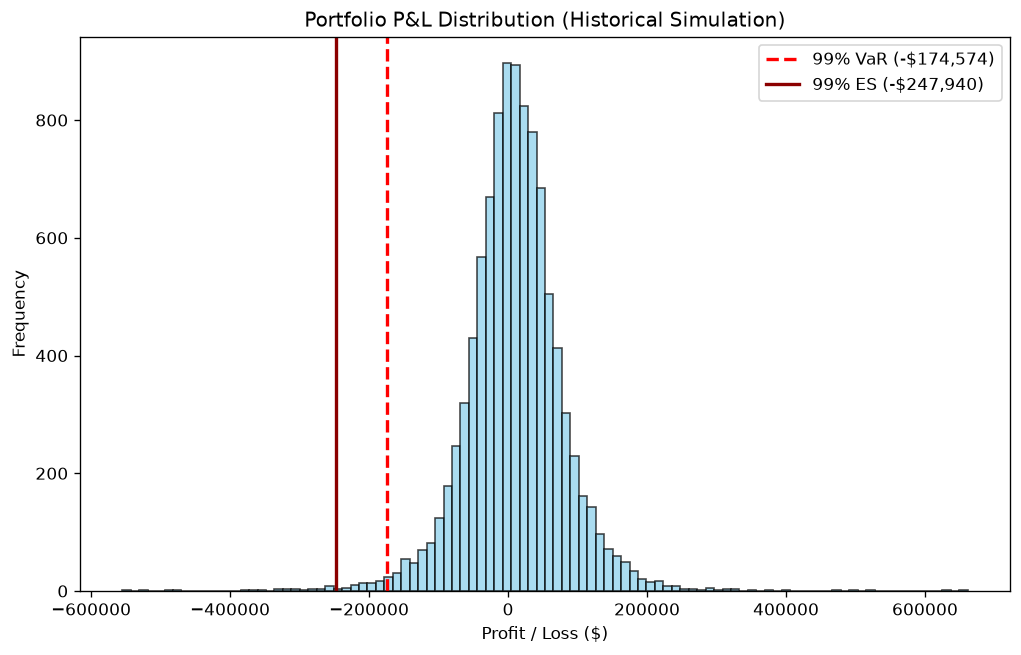

In [1]:
import sys
import os

sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
from src.portfolio.var import historical_var, historical_expected_shortfall  # noqa: E402
from src.portfolio.var import parametric_var, parametric_expected_shortfall  # noqa: E402
from src.utils.plotting import set_theme  # noqa: E402

set_theme()

# Generate a synthetic historical P&L vector (fat-tailed distribution using Student-t)
np.random.seed(42)
pnl_historical = np.random.standard_t(df=4, size=10000) * 50000 + 10000

# Calculate Historical VaR & ES at 99% confidence
hist_var = historical_var(pnl_historical, 0.99)
hist_es = historical_expected_shortfall(pnl_historical, 0.99)

print(f"Historical 99% VaR: ${hist_var:,.2f}")
print(f"Historical 99% Expected Shortfall: ${hist_es:,.2f}")

# Plotting the P&L distribution
plt.figure(figsize=(10, 6))
plt.hist(pnl_historical, bins=100, color="skyblue", edgecolor="black", alpha=0.7)
plt.axvline(
    -hist_var,
    color="red",
    linestyle="dashed",
    linewidth=2,
    label=f"99% VaR (-${hist_var:,.0f})",
)
plt.axvline(
    -hist_es,
    color="darkred",
    linestyle="solid",
    linewidth=2,
    label=f"99% ES (-${hist_es:,.0f})",
)
plt.title("Portfolio P&L Distribution (Historical Simulation)")
plt.xlabel("Profit / Loss ($)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

## Parametric VaR

In [2]:
# Parametric VaR & ES calculation
portfolio_value = 10_000_000
portfolio_duration = 7.5
yield_volatility = 0.015  # 150 bps

param_var = parametric_var(portfolio_value, portfolio_duration, yield_volatility, 0.99)
param_es = parametric_expected_shortfall(
    portfolio_value, portfolio_duration, yield_volatility, 0.99
)

print(f"Parametric 99% VaR: ${param_var:,.2f}")
print(f"Parametric 99% Expected Shortfall: ${param_es:,.2f}")

Parametric 99% VaR: $2,617,141.36
Parametric 99% Expected Shortfall: $2,998,366.00
